Considere a tabela a seguir com 10 grandes multinacionais e seus respectivos países de origem:

Empresa | País de origem
--- | ---
Exxon Mobil | 1
JP Morgan Chase | 1
General Electric | 1
Royal Dutch Shell | 2
ICBC | 3
HSBC Holdings | 4
PetroChina | 3
Berkshire Hathaway | 1
Wells Fargo | 1
Petrobras | 5

Observe que os países de origem das empresas são representados por números inteiros. Neste caso, os números são apenas rótulos para as categorias de países de origem (Estados Unidos, 1; Holanda, 2; China, 3; Reino Unido, 4; Brasil, 5). Não faz sentido somar, subtrair, multiplicar ou dividir os números que representam os países de origem das empresas. Portanto, a escala de mensuração é nominal.

In [2]:
import pandas as pd

# passando a tabela exemplo para um dicionário
empresas = {
    "Exxon Mobil": 1,
    "JP Morgan Chase": 1,
    "General Electric": 1,
    "Royal Dutch Shell": 2,
    "ICBC": 3,
    "HSBC Holdings": 4,
    "PetroChina": 3,
    "Berkshire Hathaway": 1,
    "Wells Fargo": 1,
    "Petrobras": 5,
}

# dicionário com os países
paises = {
    1: "Estados Unidos",
    2: "Holanda",
    3: "China",
    4: "Reino Unido",
    5: "Brasil",
}



In [3]:
empresas.items()

dict_items([('Exxon Mobil', 1), ('JP Morgan Chase', 1), ('General Electric', 1), ('Royal Dutch Shell', 2), ('ICBC', 3), ('HSBC Holdings', 4), ('PetroChina', 3), ('Berkshire Hathaway', 1), ('Wells Fargo', 1), ('Petrobras', 5)])

In [4]:
df_empresas = pd.DataFrame(empresas.items(), columns=["empresa", "codigo_pais"])

df_empresas

,empresa,codigo_pais
0,Exxon Mobil,1
1,JP Morgan Chase,1
2,General Electric,1
3,Royal Dutch Shell,2
4,ICBC,3
5,HSBC Holdings,4
6,PetroChina,3
7,Berkshire Hathaway,1
8,Wells Fargo,1
9,Petrobras,5


In [5]:
df_empresas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   empresa      10 non-null     str  
 1   codigo_pais  10 non-null     int64
dtypes: int64(1), str(1)
memory usage: 292.0 bytes


In [6]:
df_empresas["codigo_pais"].value_counts()

codigo_pais
1    5
3    2
2    1
4    1
5    1
Name: count, dtype: int64

In [7]:
df_empresas["codigo_pais"] = df_empresas["codigo_pais"].astype("category")

df_empresas

,empresa,codigo_pais
0,Exxon Mobil,1
1,JP Morgan Chase,1
2,General Electric,1
3,Royal Dutch Shell,2
4,ICBC,3
5,HSBC Holdings,4
6,PetroChina,3
7,Berkshire Hathaway,1
8,Wells Fargo,1
9,Petrobras,5


In [8]:
df_empresas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   empresa      10 non-null     str     
 1   codigo_pais  10 non-null     category
dtypes: category(1), str(1)
memory usage: 262.0 bytes


In [9]:
df_empresas.describe()

,empresa,codigo_pais
count,10,10
unique,10,5
top,Exxon Mobil,1
freq,1,5


In [10]:
df_empresas["codigo_pais"].cat.categories

Index([1, 2, 3, 4, 5], dtype='int64')

In [11]:
df_empresas["codigo_pais"].cat.codes

0    0
1    0
2    0
3    1
4    2
5    3
6    2
7    0
8    0
9    4
dtype: int8

In [12]:
df_empresas["codigo_pais"].cat.ordered

False

In [13]:
df_paises = pd.DataFrame(paises.items(), columns=["codigo", "pais"])

df_paises

,codigo,pais
0,1,Estados Unidos
1,2,Holanda
2,3,China
3,4,Reino Unido
4,5,Brasil


In [14]:
df_empresas.merge(df_paises, left_on="codigo_pais", right_on="codigo")

,empresa,codigo_pais,codigo,pais
0,Exxon Mobil,1,1,Estados Unidos
1,JP Morgan Chase,1,1,Estados Unidos
2,General Electric,1,1,Estados Unidos
3,Royal Dutch Shell,2,2,Holanda
4,ICBC,3,3,China
5,HSBC Holdings,4,4,Reino Unido
6,PetroChina,3,3,China
7,Berkshire Hathaway,1,1,Estados Unidos
8,Wells Fargo,1,1,Estados Unidos
9,Petrobras,5,5,Brasil


In [15]:
df_empresas.merge(df_paises, left_on="codigo_pais", right_on="codigo").drop(columns=["codigo_pais", "codigo"])

,empresa,pais
0,Exxon Mobil,Estados Unidos
1,JP Morgan Chase,Estados Unidos
2,General Electric,Estados Unidos
3,Royal Dutch Shell,Holanda
4,ICBC,China
5,HSBC Holdings,Reino Unido
6,PetroChina,China
7,Berkshire Hathaway,Estados Unidos
8,Wells Fargo,Estados Unidos
9,Petrobras,Brasil


In [16]:
df = df_empresas.merge(df_paises, left_on="codigo_pais", right_on="codigo").drop(columns=["codigo_pais", "codigo"])

df

,empresa,pais
0,Exxon Mobil,Estados Unidos
1,JP Morgan Chase,Estados Unidos
2,General Electric,Estados Unidos
3,Royal Dutch Shell,Holanda
4,ICBC,China
5,HSBC Holdings,Reino Unido
6,PetroChina,China
7,Berkshire Hathaway,Estados Unidos
8,Wells Fargo,Estados Unidos
9,Petrobras,Brasil


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   empresa  10 non-null     str  
 1   pais     10 non-null     str  
dtypes: str(2)
memory usage: 292.0 bytes


In [18]:
df.describe()

,empresa,pais
count,10,10
unique,10,5
top,Exxon Mobil,Estados Unidos
freq,1,5


In [19]:
df["pais"] = df["pais"].astype("category")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   empresa  10 non-null     str     
 1   pais     10 non-null     category
dtypes: category(1), str(1)
memory usage: 262.0 bytes


In [21]:
df["pais"].cat.categories
df["pais"].cat.codes

0    2
1    2
2    2
3    3
4    1
5    4
6    1
7    2
8    2
9    0
dtype: int8

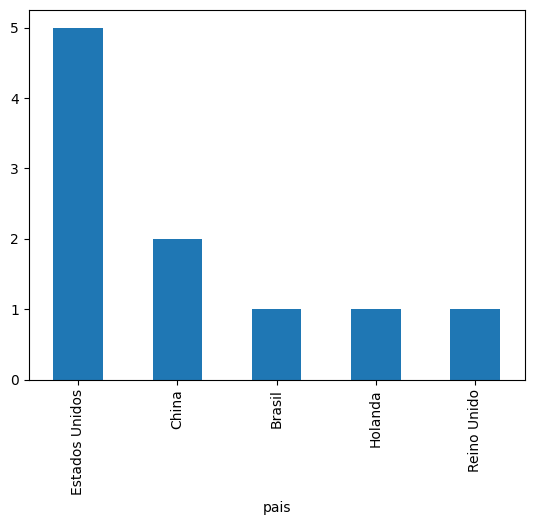

In [23]:
df["pais"].value_counts().plot(kind="bar");